In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
with open("../../data/new/agent_3/offline_episode_3_759.pkl" , 'rb') as f:
    data = pickle.load(f)
img = data[0]['camera']

In [48]:
def draw_img(img):
    img = img.astype('uint8')
    plt.imshow(img)

In [49]:
img = img[3]

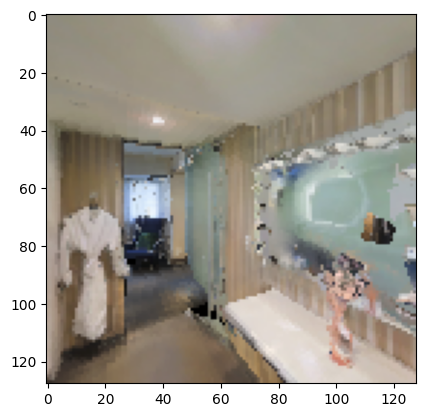

In [50]:
draw_img(img)

In [51]:
img.shape

(128, 128, 4)

In [52]:
def Gmask(img):
    height , width , _ = img.shape
    mask = np.ones((height, width),dtype=np.uint8)
    height , width = mask.shape
    for h_i in range(height):
        for w_i in range(width):
            # # left
            # if h_i + 2* w_i < 128:
            #     mask[h_i][w_i] = 0
            # # right
            # if h_i - 2* w_i < -128:
            #     mask[h_i][w_i] = 0
            if h_i - 2* w_i > -128 and h_i + 2* w_i > 128:
                mask[h_i][w_i] = 0
    return mask

In [53]:
import torch

In [79]:
mask = Gmask(img)
mask = mask[:, :, np.newaxis].astype(np.float32)
red_overlay = np.array([255.0, 0.0, 0.0 , 1], dtype=np.float32)

new_img = red_overlay*(1-mask)*img + mask*img

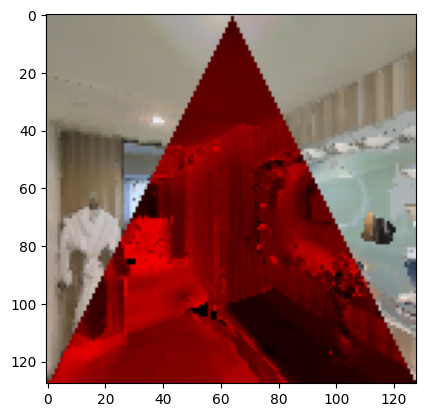

In [80]:
draw_img(new_img)